# Olist E-Commerce SQL Analysis

## by Zubeen Khalid

## Project Overview

This project analyses a real-world Brazilian e-commerce dataset published by Olist, containing 100,000 orders placed between 2016 and 2018 across multiple marketplaces in Brazil. The dataset allows an order to be viewed from multiple dimensions: order status, price, payment and freight performance, customer location, product attributes and customer reviews. A geolocation dataset linking Brazilian zip codes to coordinates 
is also included.

The data is real commercial data that has been anonymised, references to companies and partners in review text have been replaced with the names of Game of Thrones great houses.

The analysis is conducted using SQL via DuckDB within a Python environment, answering 10 business questions across four areas:

- Revenue performance
- Delivery operations
- Seller quality
- Customer behaviour

## Why This Dataset

I chose this dataset because it closely mirrors the structure of a real business database. It consists of 11 relational tables that must be joined to answer meaningful questions, rather than a single flat file. This made it a practical environment for developing SQL skills beyond basic queries.

The scale of 100,000 orders across multiple product categories, sellers and Brazilian states also means findings have genuine business weight. Patterns around delivery performance, seasonal revenue and seller quality reflect how a real marketplace actually behaved over two years.



## Tools Used

- **Python:**  data loading and environment setup  
- **DuckDB:** in-memory SQL engine used to query pandas DataFrames  
- **pandas:** data ingestion exploratory data analysis

## Data Quality Findings

Before any analysis, a full data quality review is conducted. 
Key issues include:

- **Timestamps stored as strings** in three tables, requiring CAST to DATE before 
  any date calculations could be performed
- **2,965 orders with no delivery date** recorded, meaning on-time delivery figures 
  are a minimum estimate rather than a complete picture
- **610 products with missing category names**, handled by using a LEFT JOIN to 
  preserve all products in revenue calculations
- **Column name typos** in the Products table (`product_name_lenght`) queries 
  must use the misspelled version until the source data is corrected
- **High null counts in the Closed Deals table** flagged for further investigation 
  before use in any marketing funnel analysis

## Key Findings

**Revenue**
- Health and Beauty is the top performing category with BRL 1,258,681 in total revenue and a strong average review score of 4.14
- Monthly revenue grew from BRL 120,000 in January 2017 to BRL 1,000,000 by early 2018, indicating strong platform growth
- November 2017 produced the highest single month revenue of BRL 1,010,271, consistent with Black Friday demand

**Delivery**
- 89.15% of orders are delivered on time, though this figure excludes 2,965 orders with no delivery date; the true rate may be lower
- On average, orders arrive 11.87 days earlier than the estimated delivery date, suggesting Olist's estimates are deliberately or inadvertently conservative

**Sellers**
- 9 out of 10 top revenue-generating sellers are based in São Paulo, revealing significant geographic concentration risk
- 6 out of 465 qualifying sellers score below 3.0 in average review score. Three of these have over 100 orders each, meaning hundreds of customers have experienced consistently poor service
- For 4 of the 6 underperforming sellers, on-time delivery rates between 64% and 75% identify logistics as the primary issue rather than product quality

**Customer Behaviour**
- Average transaction value is BRL 161, but this varies significantly by category. For Example: computers average BRL 1,098 per order while home comfort items average BRL 25
- São Paulo generates 47,449 orders and BRL 5,202,955 in revenue, roughly three times more than the second largest state, Rio de Janeiro

## Business Recommendations

The following highlights the highest-impact recommendations. Detailed recommendations for each business question are available throughout the notebook.

**Revenue & Marketing**
- Prioritise Health and Beauty, Watches and Gifts, and Cool Stuff for marketing investment; these three categories combine high revenue, strong review scores and clear growth potential
- Target Watches and Gifts campaigns around Christmas, Valentine's Day and Mother's Day when gifting demand peaks
- Capitalise on the Black Friday opportunity identified in November 2017 and ensure that sellers are stocked and logistics are prepared ahead of time each year
- Discontinue or review low-performing categories including CDs/DVDs, Flowers and Diapers where revenue is low and structural decline is likely to continue

**Delivery**
- Make recording delivery dates mandatory for all sellers. 2,965 missing delivery records currently make it impossible to accurately measure performance
- Update delivery estimates to reflect the actual 11.87 day early delivery average, as more accurate estimates would improve customer trust and serve as a competitive differentiator

**Sellers**
- Immediately investigate the 6 sellers scoring below 3.0 review score. 3 of them have over 100 orders each, meaning the customer impact is already significant
- Introduce a minimum review score threshold and a structured improvement plan before any removal decision is made

**Geographic Growth**
- Reduce overdependence on São Paulo by running targeted campaigns in MG, RS and PR, and exploring logistics partnerships in northern states


## SQL Techniques Used

- INNER JOIN, LEFT JOIN across multiple tables  
- Aggregate functions: SUM, AVG, COUNT, ROUND  
- GROUP BY, HAVING, ORDER BY  
- Subqueries and CTEs (Common Table Expressions)  
- CASE WHEN for conditional logic  
- DATE_TRUNC and CAST for date handling  
- DATEDIFF for calculating delivery windows  
- ANY_VALUE for non-grouped columns

# Table of Contents

1. [Loading Data](#loading-data)
   - [Brazilian E-Commerce Dataset](#brazilian-e-commerce-dataset)
   - [Marketing Funnel Dataset](#marketing-funnel-dataset)
2. [Business Questions Overview](#business-questions-overview)
3. [Data Quality Checks](#data-quality-checks)
   - [Total Orders Per Seller](#total-orders-per-seller)
   - [Findings from Data Quality Checks](#findings-from-data-quality-checks)
4. [Business Question 1: Revenue by Product Category](#business-question-1)
5. [Business Question 2: Monthly Revenue Trend](#business-question-2)
6. [Business Question 3: On-Time Delivery Rate](#business-question-3)
7. [Business Question 4: Actual vs Estimated Delivery Time](#business-question-4)
8. [Business Question 5: Top Revenue Sellers](#business-question-5)
9. [Business Question 6: Seller Review Scores](#business-question-6)
10. [Business Question 7: Delivery vs Product Quality](#business-question-7)
11. [Business Question 8: Average Transaction Value](#business-question-8)
12. [Business Question 9: Orders and Revenue by State](#business-question-9)
13. [Business Question 10: Categories to Prioritise for Marketing](#business-question-10)

In [217]:
!pip install duckdb

In [218]:
# importing libraries

import pandas as pd
import duckdb as db
import matplotlib.pyplot as plt
import seaborn as sns

<a id='loading-data'></a>
# Loading Data from Olist dataset

## Brazilian E-Commerce Public Dataset by Olist
100,000 Orders with product, customer and reviews info

In [220]:
customer_df = pd.read_csv(r"..\data\olist_customers_dataset.csv")

In [221]:
geo_location_df = pd.read_csv(r"..\data\olist_geolocation_dataset.csv")

In [222]:
order_items_df = pd.read_csv(r"..\data\olist_order_items_dataset.csv")

In [223]:
order_payments_df = pd.read_csv(r"..\data\olist_order_payments_dataset.csv")

In [224]:
order_reviews_df = pd.read_csv(r"..\data\olist_order_reviews_dataset.csv")

In [225]:
orders_df = pd.read_csv(r"..\data\olist_orders_dataset.csv")

In [226]:
products_df = pd.read_csv(r"..\data\olist_products_dataset.csv")

In [227]:
sellers_df = pd.read_csv(r"..\data\olist_sellers_dataset.csv")

In [228]:
product_category_name_translation = pd.read_csv(r"..\data\product_category_name_translation.csv")

## Marketing Funnel by Olist
8k leads, closed deals and connection to 100k orders

In [230]:
closed_deals_df = pd.read_csv(r"..\data\olist_closed_deals_dataset.csv")

In [231]:
marketing_qualified_leads_df = pd.read_csv(r"..\data\olist_marketing_qualified_leads_dataset.csv")

In [232]:
customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [233]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [234]:
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [235]:
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [236]:
geo_location_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [237]:
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [238]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [239]:
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [240]:
product_category_name_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [241]:
closed_deals_df.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0


In [242]:
marketing_qualified_leads_df.head()

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


<a id='business-questions-overview'></a>
# Business Questions Overview

## Revenue

- Which product categories generate the highest and lowest revenue?
- Is monthly revenue growing or declining over time?

## Delivery

- What percentage of orders are delivered on time?
- How does actual delivery time compare to the estimated delivery date?

## Sellers

- Which sellers generate the most revenue?
- Which sellers have the highest and lowest average review scores?
- For underperforming sellers, is the issue delivery speed or product quality?

## Customer behaviour

- What is the average amount a customer spends on a single transaction?
- Which states generate the most orders and revenue?

## Synthesis

- Based on revenue, growth and reviews: which product categories should be prioritised in future marketing?

<a id='data-quality-checks'></a>
## Data Quality Checks

In [245]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [246]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [247]:
geo_location_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [248]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [249]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [250]:
products_df.info()

# missing info in some columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [251]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [252]:
product_category_name_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [253]:
marketing_qualified_leads_df.info()

#date as string

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   mql_id              8000 non-null   object
 1   first_contact_date  8000 non-null   object
 2   landing_page_id     8000 non-null   object
 3   origin              7940 non-null   object
dtypes: object(4)
memory usage: 250.1+ KB


In [254]:
customer_df.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [255]:
geo_location_df.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [256]:
order_items_df.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

<a id='total-orders-per-seller'></a>
## TOTAL ORDERS PER SELLER

In [258]:
orders_per_seller = order_items_df.groupby('seller_id')['order_id'].nunique()

print(orders_per_seller)

sellers_with_10_plus_orders = (orders_per_seller > 10).sum()
print(f"Total no. of sellers with 10+ orders: {sellers_with_10_plus_orders}")

sellers_with_50_plus_orders = (orders_per_seller > 50).sum()
print(f"Total no. of sellers with 50+ orders: {sellers_with_50_plus_orders}")

sellers_with_100_plus_orders = (orders_per_seller > 100).sum()
print(f"Total no. of sellers with 100+ orders: {sellers_with_100_plus_orders}")

seller_id
0015a82c2db000af6aaaf3ae2ecb0532      3
001cca7ae9ae17fb1caed9dfb1094831    200
001e6ad469a905060d959994f1b41e4f      1
002100f778ceb8431b7a1020ff7ab48f     51
003554e2dce176b5555353e4f3555ac8      1
                                   ... 
ffcfefa19b08742c5d315f2791395ee5      1
ffdd9f82b9a447f6f8d4b91554cc7dd3     18
ffeee66ac5d5a62fe688b9d26f83f534     14
fffd5413c0700ac820c7069d66d98c89     60
ffff564a4f9085cd26170f4732393726     20
Name: order_id, Length: 3095, dtype: int64
Total no. of sellers with 10+ orders: 1201
Total no. of sellers with 50+ orders: 421
Total no. of sellers with 100+ orders: 210


In [259]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [260]:
order_payments_df.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [261]:
order_reviews_df.isnull().sum()

# missing data

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [262]:
orders_df.isnull().sum()

# missing data

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [263]:
products_df.isnull().sum()

#missing data

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [264]:
sellers_df.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [265]:
product_category_name_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [266]:
closed_deals_df.isnull().sum()

# missing data

mql_id                             0
seller_id                          0
sdr_id                             0
sr_id                              0
won_date                           0
business_segment                   1
lead_type                          6
lead_behaviour_profile           177
has_company                      779
has_gtin                         778
average_stock                    776
business_type                     10
declared_product_catalog_size    773
declared_monthly_revenue           0
dtype: int64

In [267]:
marketing_qualified_leads_df.isnull().sum()

#missing data

mql_id                 0
first_contact_date     0
landing_page_id        0
origin                60
dtype: int64

<a id='findings-from-data-quality-checks'></a>
## Findings from Data Quality Checks

### 1. Timestamps Stored as Strings
The following date columns are stored as string datatype instead of datetime:

- **Orders table:** order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date
- **Order Reviews table:** review_creation_date, review_answer_timestamp
- **Marketing Qualified Leads table:** first_contact_date

**Why it matters:** Dates stored as strings prevent SQL from performing date calculations such as delivery time and monthly trends.

### 2. Missing Data

**Products table**

| Column | Missing Rows |
|---|---|
| product_category_name | 610 |
| product_name_lenght | 610 |
| product_description_lenght | 610 |
| product_photos_qty | 610 |
| product_weight_g | 2 |
| product_length_cm | 2 |
| product_height_cm | 2 |
| product_width_cm | 2 |

**Order Reviews table**

| Column | Missing Rows |
|---|---|
| review_comment_title | 87,656 |
| review_comment_message | 58,247 |

*Decision: Ignore as review comments are optional. Review score is what matters for analysis.*

**Orders table**

| Column | Missing Rows |
|---|---|
| order_approved_at | 160 |
| order_delivered_carrier_date | 1783 |
| order_delivered_customer_date | 2965 |

*Decision: Flag as critical limitation as 2,965 orders have no delivery date recorded, meaning actual delivery performance cannot be accurately measured.*

**Closed Deals table**

| Column | Missing Rows |
|---|---|
| business_segment | 1 |
| lead_type | 6 |
| lead_behaviour_profile | 177 |
| has_company | 779 |
| has_gtin | 778 |
| average_stock | 776 |
| business_type | 10 |
| declared_proasuct_catalog_size | 773 |

*Decision: Investigate further as high null counts need explanation before using this table in analysis.*

**Marketing Qualified Leads table**

| Column | Missing Rows |
|---|---|
| origin | 60 |

*Decision: Flag as limitation as origin is used in channel analysis, 60 missing rows may affect results.*

**Why it matters:** Missing values can lead to incomplete or misleading analysis. Each case has been assessed individually above.

### 3. Spelling Errors / Typos

The Products table contains typos in two column names:
- `product_name_lenght` should be `product_name_length`
- `product_description_lenght` should be `product_description_length`

**Why it matters:** Referencing the correct spelling in a SQL query will throw an error because the actual column is misspelled. Queries must use the misspelled version until fixed.

### 4. Todo
- [ ] Convert date columns to datetime datatype before loading into DuckDB
- [ ] Fix typos in Products table column names
- [ ] Investigate high null counts in Closed Deals table
- [ ] Flag Orders table delivery date nulls as a limitation in final analysis
- [ ] Ignore null values where columns are non-critical (review comments, product dimensions)

In [269]:
# DuckDb

connection = db.connect(':memory:')

In [270]:
connection.register("orders",orders_df)
connection.register("customer", customer_df)
connection.register("location", geo_location_df)
connection.register("order_item", order_items_df)
connection.register("payment", order_payments_df)
connection.register("reviews", order_reviews_df)
connection.register("products", products_df)
connection.register("sellers", sellers_df)
connection.register("product_name_english", product_category_name_translation)
connection.register("closed_deals", closed_deals_df)
connection.register("marketing", marketing_qualified_leads_df)

In [271]:
connection.execute("""SELECT *
                  FROM orders
                  LIMIT 5; """).df()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


SQL query to find categories generating the highest and lowest revenue.

- Revenue comes from **order_items** table
- Product category names come from **products** table
- These two tables connect through **product_id** field
- Category names are in Portuguese: the English translations is available in **product_name_english** table

In [273]:
# Query 1: joining order_item and product table

connection.execute("""
                    SELECT order_item.product_id, SUM(order_item.price) AS total_revenue
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    GROUP BY order_item.product_id
                    ORDER BY total_revenue DESC
                    LIMIT 10;
                    """).df()

,product_id,total_revenue
0,bb50f2e236e5eea0100680137654686c,63885.00
1,6cdd53843498f92890544667809f1595,54730.20
2,d6160fb7873f184099d9bc95e30376af,48899.34
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
4,99a4788cb24856965c36a24e339b6058,43025.56
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60
6,25c38557cf793876c5abdd5931f922db,38907.32
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90
8,53b36df67ebb7c41585e8d54d6772e08,37683.42
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90


In [274]:
# 2: Joining with product category names table
# Getting top 10 products with highest revenue 

connection.execute("""
                    SELECT eng.product_category_name_english AS product_name, SUM(order_item.price) AS total_revenue
                    
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english
                    ORDER BY total_revenue DESC
                    LIMIT 10;
                    """).df()

,product_name,total_revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


<Figure size 1400x600 with 0 Axes>

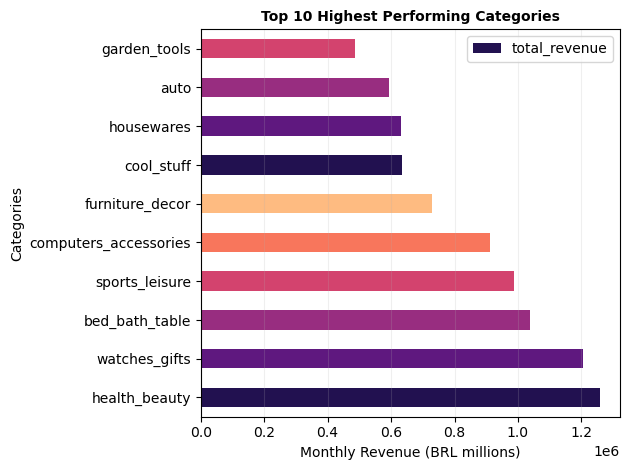

In [427]:
# just assign it to a variable
highest_revenue = connection.execute("""
                    SELECT eng.product_category_name_english AS product_name, SUM(order_item.price) AS total_revenue
                    
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english
                    ORDER BY total_revenue DESC
                    LIMIT 10;
                    """).df()


plt.figure(figsize = (14,6))
colors = sns.color_palette("magma")

highest_revenue.plot(kind='barh',  x = 'product_name', y='total_revenue',color = colors)
plt.xlabel('Monthly Revenue (BRL millions)')
plt.ylabel('Categories')
plt.title('Top 10 Highest Performing Categories', fontsize = 10, weight = 'bold')
plt.grid(axis = 'x', alpha = 0.2)
plt.tight_layout()
plt.savefig('top_10_highest_performing_categories',bbox_inches="tight")
plt.show()

In [276]:
# 3: Getting top 10 products with lowest revenue


connection.execute("""
                    SELECT eng.product_category_name_english AS product_name, SUM(order_item.price) AS total_revenue
                    
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english
                    ORDER BY total_revenue ASC
                    LIMIT 10;
                    """).df()

,product_name,total_revenue
0,security_and_services,283.29
1,fashion_childrens_clothes,569.85
2,cds_dvds_musicals,730.00
3,home_comfort_2,760.27
4,flowers,1110.04
5,diapers_and_hygiene,1567.59
6,arts_and_craftmanship,1814.01
7,la_cuisine,2054.99
8,fashion_sport,2119.51
9,fashio_female_clothing,2803.64


<Figure size 1400x600 with 0 Axes>

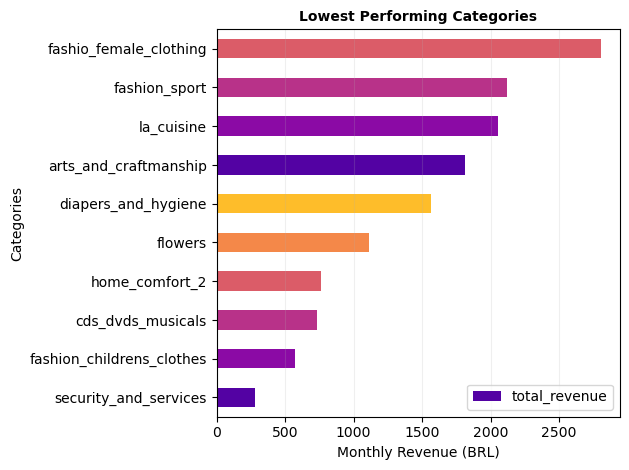

In [421]:
lowest_revenue = connection.execute("""
                    SELECT eng.product_category_name_english AS product_name, SUM(order_item.price) AS total_revenue
                    
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english
                    ORDER BY total_revenue ASC
                    LIMIT 10;
                    """).df()

plt.figure(figsize = (14,6))
colors = sns.color_palette("plasma")

lowest_revenue.plot(kind='barh',  x = 'product_name', y='total_revenue',color = colors)
plt.xlabel('Monthly Revenue (BRL)')
plt.ylabel('Categories')
plt.title('Lowest Performing Categories', fontsize = 10, weight = 'bold')
plt.grid(axis = 'x', alpha = 0.2)
plt.tight_layout()
plt.savefig('lowest_performing_categories')
plt.show()

<a id='business-question-1'></a>
## Business Question 1
"Which product categories generate the highest and lowest revenue?"

### Which tables are joined and why
I joined the Order Items, Products and Product Name English tables. These contain the key information about products sold and their price. As the original category names were in Portuguese, it was necessary to join the English translation table.

### Key Findings: Highest Revenue
The top performing category is Health and Beauty, generating total revenue of BRL 1,258,681.34. The top 10 highest performing categories include costly and luxury items such as gifts, watches, home and computer items. It is surprising to see how the Cool Stuff category generated BRL 635,290.85, showing that trending items can significantly boost sales.

### Key Findings: Lowest Revenue
The lowest revenue categories include children's clothing, diapers and hygiene, fashion sport and female clothing, which is surprising as these items are normally high in demand. CDs, DVDs and Musicals is a niche category and with the rise of online streaming apps, demand is likely to continue falling. Flowers generate low revenue as customers prefer to buy fresh from local stores.

The lowest revenue product is Security and Services, generating only BRL 283.29, which is surprising given rising safety concerns and the typically high cost of security products.

There is a considerable gap between the highest and lowest performing categories.

### Business Recommendations
- Olist should invest more in promoting Health and Beauty and Gift items as these are consistently high in demand. Cool Stuff should also be actively promoted given its strong performance.
- More variety should be introduced in the female clothing range. Improving quality and stocking current fashion styles could significantly improve revenue in this category.
- It is recommended to discontinue CDs, DVDs and Musicals as revenue is likely to continue declining due to streaming platforms.
- Flowers should be discontinued or Olist should consider partnering with local flower shops to offer fresh, locally delivered flowers to customers.
- Diapers should be reconsidered as large box sizes result in high delivery costs, pushing customers towards supermarkets instead.
- Further investigation is needed for children's fashion. Stocking popular children's brands could boost revenue in this category.

In [279]:
# Business Question 2: Is monthly revenue growing or declining over time?

# table that contains both the price and a date column: order_item and orders
# For date column, it makes more sense to use order_purchase_timestamp from the 'orders' table
# Both columns could be joined using order_id

# "monthly revenue" mean in SQL terms — what are you grouping by and what are you aggregating? aggregating total revenue per month for each year available in the data

In [280]:
connection.execute("""
                   SELECT SUM(price) AS total_revenue, DATE_TRUNC('month', CAST(order_purchase_timestamp AS DATE)) AS month
                   FROM order_item
                   LEFT JOIN orders
                   ON order_item.order_id = orders.order_id
                   GROUP BY month
                   ORDER BY month
                  
                   """).df()

,total_revenue,month
0,267.36,2016-09-01
1,49507.66,2016-10-01
2,10.90,2016-12-01
3,120312.87,2017-01-01
4,247303.02,2017-02-01
5,374344.30,2017-03-01
6,359927.23,2017-04-01
7,506071.14,2017-05-01
8,433038.60,2017-06-01
9,498031.48,2017-07-01


<a id='business-question-2'></a>
## Business Question 2: Is Monthly Revenue Growing or Declining Over Time?

### Tables Used
Order Items and Orders tables, joined on order_id. The purchase timestamp from the Orders table was truncated to month level using DATE_TRUNC to aggregate revenue by month.

### Overall Trend
From September 2016 to August 2018, the overall trend shows consistent growth with some fluctuations. Monthly revenue grew from approximately BRL 120,000 in January 2017 to nearly BRL 1,000,000 by early 2018, indicating strong business growth over this period.

### Anomalies and Explanations
**Partial months - not concerning:**
- September 2016 (BRL 267.36) - this is the first month of recorded sales. It is likely that trading did not begin at the start of the month, making this figure unrepresentative of a full month.
- September 2018 (BRL 145.00) - this is the last month in the dataset and almost certainly represents only a few days of trading rather than a full month.

**Unexplained anomaly - requires investigation:**
- December 2016 (BRL 10.90) - this figure is not realistic for a full month of trading on a growing platform, particularly given that December is a peak shopping period due to Christmas. This may indicate a data collection issue or a gap in the dataset and should be treated with caution in any analysis.

**Missing data:**
- November 2016 is absent from the dataset entirely. This makes it impossible to compare November performance year on year, as only one November figure (2017) is available.

**Revenue spike:**
- November 2017 (BRL 1,010,271.37) - the highest revenue month in the dataset. This spike is consistent with Black Friday, a major global shopping event that has grown significantly in Brazil in recent years.

### Business Recommendation

The strong upward trend from 2017 into 2018 suggests Olist was in a healthy growth phase.

- The Black Friday spike in November 2017 represents a significant commercial opportunity
- Olist should ensure sellers are adequately stocked and logistics are prepared ahead of Black Friday each year.
- The December 2016 anomaly should be investigated further before drawing any conclusions about December trading performance.

In [282]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [283]:
revenue = order_items_df[['order_id','price']]
revenue.head()

,order_id,price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [284]:
# 1. Convert to datetime
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

# 2. Extract month + year
orders_df['month_num'] = orders_df['order_purchase_timestamp'].dt.month
orders_df['year'] = orders_df['order_purchase_timestamp'].dt.year
orders_df['month_year'] = orders_df['order_purchase_timestamp'].dt.strftime('%b-%Y')

# 3. Create order_per_month table
order_per_month = orders_df[['order_id', 'month_num', 'month_year']]

# 4. Merge with revenue
revenue_per_month = order_per_month.merge(revenue, how='inner', on='order_id')

# 5. Convert month_year to datetime for correct sorting
revenue_per_month['month_year'] = pd.to_datetime(revenue_per_month['month_year'], format='%b-%Y')

# 6. Group and sort
monthly_revenue = (revenue_per_month.groupby('month_year')['price'].sum().rename('monthly_total').sort_index())

# 7. Convert index back to "Apr-2017" format
monthly_revenue.index = monthly_revenue.index.strftime('%b-%Y')

monthly_revenue


month_year
Sep-2016        267.36
Oct-2016      49507.66
Dec-2016         10.90
Jan-2017     120312.87
Feb-2017     247303.02
Mar-2017     374344.30
Apr-2017     359927.23
May-2017     506071.14
Jun-2017     433038.60
Jul-2017     498031.48
Aug-2017     573971.68
Sep-2017     624401.69
Oct-2017     664219.43
Nov-2017    1010271.37
Dec-2017     743914.17
Jan-2018     950030.36
Feb-2018     844178.71
Mar-2018     983213.44
Apr-2018     996647.75
May-2018     996517.68
Jun-2018     865124.31
Jul-2018     895507.22
Aug-2018     854686.33
Sep-2018        145.00
Name: monthly_total, dtype: float64

**A month‑by‑month view of how revenue evolved over time.**

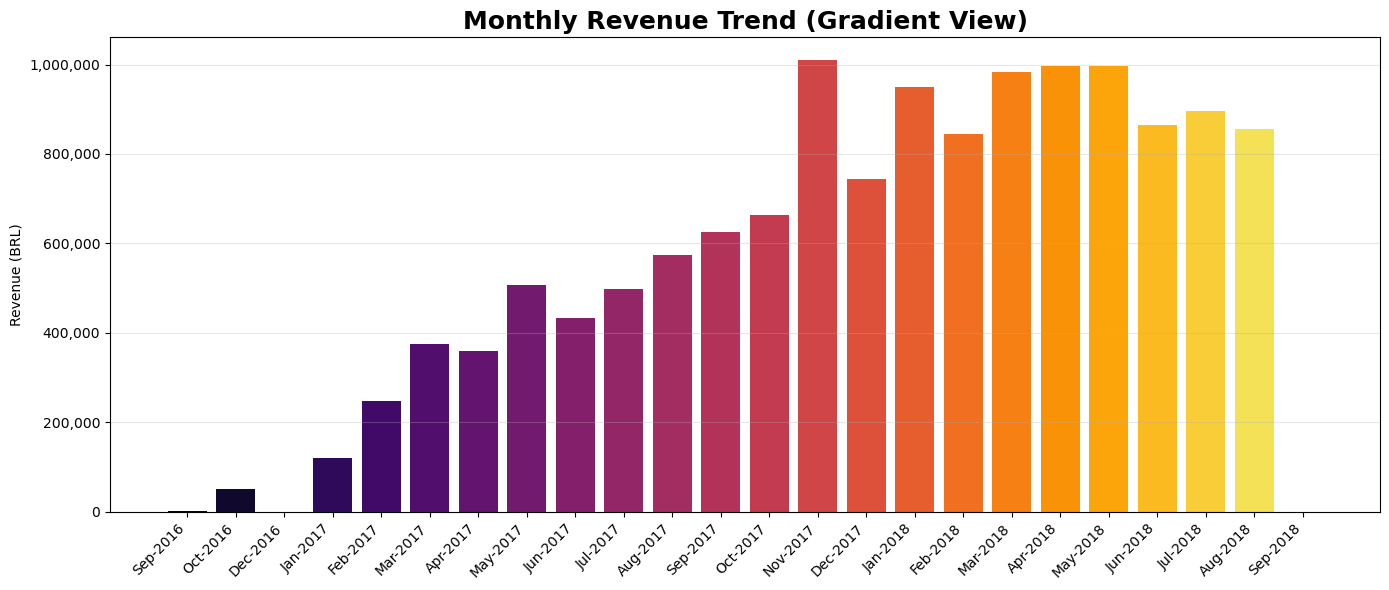

In [423]:
import matplotlib.ticker as mtick
import numpy as np

plt.figure(figsize=(14,6))

colors = sns.color_palette("inferno", len(monthly_revenue))

plt.bar(monthly_revenue.index, monthly_revenue.values, color=colors)

plt.xticks(rotation=45, ha='right')


ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.title('Monthly Revenue Trend (Gradient View)', fontsize=18, weight='bold')
plt.ylabel('Revenue (BRL)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_revenue_trend')
plt.show()


In [287]:
# Business Question 3 bout delivery
# What percentage of orders are delivered on time?


In [288]:
connection.execute("""
                   SELECT SUM(on_time) AS delivered_on_time,
                          COUNT(*) AS total_orders, 
                          ROUND(SUM(on_time) * 100.0 / COUNT(*), 2) AS percentage_on_time
                          
                          
                   FROM 
                    (SELECT CAST(order_delivered_customer_date AS DATE) AS delivery_date, 
                          CAST(order_estimated_delivery_date AS DATE) AS estimated_delivery,
                          (CASE WHEN delivery_date < estimated_delivery THEN 1
                          ELSE 0 END) AS on_time
                          FROM orders) AS delivery_check;""").df()

,delivered_on_time,total_orders,percentage_on_time
0,88649.0,99441,89.15


<a id='business-question-3'></a>
## Business Question 3: What Percentage of Orders Are Delivered on Time?

### Tables Used and Approach
The Orders table was used, extracting order_delivered_customer_date and 
order_estimated_delivery_date. As both columns were stored as strings, 
they were converted to date format using CAST before comparison. An order 
was defined as 'on time' if the actual delivery date was earlier than the 
estimated delivery date.

### Key Finding
**89.15% of orders are delivered on time**

While this is an encouraging figure at first glance, it means that 
approximately 1 in 10 customers does not receive their order on time. 
At scale, this represents a significant number of customers experiencing 
poor delivery service, which directly impacts customer retention, 
repeat purchases and review scores.

### Data Limitation
2,965 orders had no delivery date recorded and were excluded from this 
analysis. These missing dates could represent:
- Orders that were never delivered
- Orders lost in transit
- A failure in data collection by sellers

This means the 89.15% figure may not reflect the full picture. If a 
proportion of these 2,965 orders were never delivered, the true on-time 
delivery rate could be lower than reported.

### Business Recommendations
- Olist should make recording delivery dates mandatory for all sellers. 
  Missing delivery data makes it impossible to accurately measure 
  performance and hold sellers accountable.
- The 2,965 orders with no delivery date should be investigated as a 
  priority. Olist should identify whether these customers received their 
  orders and follow up directly where they did not.
- Sellers with consistently late deliveries should be contacted to 
  understand the root cause whether it is logistics, stock availability 
  or operational issues.
- Improving on-time delivery should be treated as a key business priority. 
  Late deliveries lead to negative reviews, reduced customer retention and 
  loss of repeat revenue.

In [290]:
#Business Question 4:
# How does actual delivery time compare to the estimated delivery date?

In [291]:
orders_df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
month_num                           0
year                                0
month_year                          0
dtype: int64

In [292]:
# missing 2965 orders delivery date
# total orders 99441
# after excluding missing delivered orders total is 96476


connection.execute("""
                   SELECT AVG(date_difference) AS date_difference
                   FROM
                   (SELECT DATEDIFF('day', CAST(order_delivered_customer_date AS DATE) ,
                   CAST(order_estimated_delivery_date AS DATE)) AS date_difference 
                   FROM orders
                   WHERE order_delivered_customer_date IS NOT NULL)
                   """).df()

,date_difference
0,11.876881


<a id='business-question-4'></a>
## Business Question 4: 
How Does Actual Delivery Time Compare to the Estimated Delivery Date?

### Tables Used and Approach
- The Orders table was used, extracting order_delivered_customer_date and 
order_estimated_delivery_date.
- Both columns were converted from string to date format using CAST. DATEDIFF was used to calculate the number of days 
between actual and estimated delivery.
- Orders with no recorded delivery date were excluded using a WHERE clause. The average difference was 
calculated using a subquery.

### Key Finding
**On average, orders are delivered 11.87 days earlier than the estimated 
delivery date.**

This positive figure means that the majority of orders arrive almost 2 
weeks ahead of schedule. Combined with the finding from Business Question 3 
that 89.15% of orders are delivered on time, this suggests that Olist's 
delivery estimates are significantly more conservative than actual 
delivery performance.

Whether this pattern is consistent across all Brazilian states will be explored in Business Question 9.

### What This Means for the Business

**Positive implications:**
- Customers are pleasantly surprised when orders arrive earlier than 
  expected, which encourages positive reviews and repeat purchases.
- Early delivery builds customer trust and satisfaction.

**Concerning implications:**
- Estimates that are too conservative may cause customers to choose a 
  competitor who advertises faster delivery, without knowing that Olist 
  actually delivers sooner in practice.
- Customers who pay premium charges for express delivery may not realise 
  that standard delivery would have arrived just as quickly.
- The key unanswered question is whether these conservative estimates are 
  deliberate policy or an oversight; this requires further investigation.

### Business Recommendations
- Olist should investigate whether the 11.87 day early delivery average 
  is consistent across all regions and sellers, or whether it varies 
  significantly.
- If the pattern is consistent, Olist should consider updating its 
  delivery estimates to better reflect actual performance. More accurate 
  estimates would improve customer trust and could be used as a 
  competitive advantage.
- Marketing should consider promoting faster than expected delivery as 
  a key differentiator. For example: *"We deliver faster than we promise"* is a 
  powerful customer message.
- A review of express delivery pricing is recommended to ensure customers 
  are not paying unnecessarily for a service standard delivery already meets.

In [294]:
# Business Question 5: Which sellers generate the most revenue?
# from order_item table get seller_id and price

In [295]:
connection.execute("""
                   SELECT  order_item.seller_id, COUNT(order_id) AS total_orders, ROUND(AVG(price), 2) AS average_order_value, 
                   SUM(price) AS total_revenue, 
                   ANY_VALUE(business_segment) AS item_category, ANY_VALUE(seller_state) AS seller_state
                   
                   FROM order_item
                   LEFT JOIN closed_deals
                   ON order_item.seller_id = closed_deals.seller_id
                   LEFT JOIN sellers
                   ON order_item.seller_id = sellers.seller_id
                   GROUP BY order_item.seller_id
                   ORDER BY total_revenue DESC
                   LIMIT 10;
                   """).df()

,seller_id,total_orders,average_order_value,total_revenue,item_category,seller_state
0,4869f7a5dfa277a7dca6462dcf3b52b2,1156,198.51,229472.63,None,SP
1,53243585a1d6dc2643021fd1853d8905,410,543.36,222776.05,None,BA
2,4a3ca9315b744ce9f8e9374361493884,1987,100.89,200472.92,None,SP
3,fa1c13f2614d7b5c4749cbc52fecda94,586,331.13,194042.03,None,SP
4,7c67e1448b00f6e969d365cea6b010ab,1364,137.77,187923.89,None,SP
5,7e93a43ef30c4f03f38b393420bc753a,340,518.92,176431.87,None,SP
6,da8622b14eb17ae2831f4ac5b9dab84a,1551,103.31,160236.57,None,SP
7,7a67c85e85bb2ce8582c35f2203ad736,1171,121.05,141745.53,None,SP
8,1025f0e2d44d7041d6cf58b6550e0bfa,1428,97.32,138968.55,None,SP
9,955fee9216a65b617aa5c0531780ce60,1499,90.17,135171.70,None,SP


<a id='business-question-5'></a>
## Business Question 5: 
Which Sellers Generate the Most Revenue?

### Tables Used and Approach
The Order Items, Sellers and Closed Deals tables were joined using seller_id. 
Revenue, total orders and average order value were calculated per seller. 
Results were limited to the top 10 sellers by total revenue.

### Key Findings

**Geographic concentration:**
9 out of 10 top performing sellers are located in São Paulo (SP), 
confirming that Olist's seller base and commercial activity is heavily 
concentrated in Brazil's largest economic hub. The only exception is the 
number 2 seller, located in Bahia (BA), who despite having only 410 orders 
achieves the highest average order value of BRL 543.36 suggesting a 
premium or specialist product offering.

**Volume vs Value:**
There are two distinct seller strategies visible in the top 10:
- High value, lower volume sellers: the top seller generates BRL 229,472.63 from 1,156 orders at an average of BRL 198.51 per order
- High volume, lower value sellers: the 10th seller processed 1,499 orders but at only BRL 90.17 average, generating BRL 135,171.70 in total revenue. This suggests that selling higher value items is a more effective revenue 
strategy than high volume alone.

**Data Limitation:**
Business segment data is unavailable for all top 10 sellers, as none of 
them appear in the Closed Deals table. This means these sellers were not 
acquired through the tracked marketing funnel, limiting our ability to 
analyse their acquisition channel. This raises serious questions about whether the current marketing efforts are targeting the right seller profiles.

### Business Recommendations
- Olist should investigate what product categories the top SP sellers 
  operate in and replicate their model in other states to reduce 
  geographic dependency.
- The BA seller's high average order value warrants further investigation, understanding their product category could inform a premium seller 
  acquisition strategy.
- Olist should improve seller tracking so that business segment data is 
  captured for all sellers, not just those acquired through the marketing 
  funnel.
- Olist should investigate how these high performing sellers were acquired and use those findings to reassess current campaign strategy. By attracting more sellers with similar profiles could significantly increase revenue.

In [297]:
# Business Question 6: Which sellers have the highest and lowest average review scores?
# order_item (col: order_id, seller_id) , reviews table (order_id, review_score)

In [298]:
connection.execute("""
                   SELECT COUNT(order_item.order_id) AS total_orders, seller_id, ROUND(AVG(review_score),2) AS avg_review_score
                   
                   FROM order_item
                   
                   LEFT JOIN reviews
                   
                   ON order_item.order_id = reviews.order_id
                   WHERE review_score IS NOT NULL
                   GROUP BY seller_id
                   HAVING COUNT(order_item.order_id) >= 50
                   ORDER BY avg_review_score DESC
                   
                   
                   """).df()

,total_orders,seller_id,avg_review_score
0,61,d9bd94811c3338dceb4181f3dbc0c73e,4.82
1,69,d13e50eaa47b4cbe9eb81465865d8cfc,4.81
2,55,83e197e95a1bbabc8c75e883ed016c47,4.75
3,71,d566c37fa119d5e66c4e9052e83ee4ea,4.72
4,58,376a891762bbdecbc02b4b6adec3fdda,4.67
...,...,...,...
460,106,a49928bcdf77c55c6d6e05e09a9b4ca5,2.95
461,81,54965bbe3e4f07ae045b90b0b8541f52,2.94
462,59,602044f2c16190c2c6e45eb35c2e21cb,2.93
463,209,2eb70248d66e0e3ef83659f71b244378,2.71


In [299]:
connection.execute("""
                   SELECT COUNT(order_item.order_id) AS total_orders, seller_id, ROUND(AVG(review_score),2) AS avg_review_score
                   
                   FROM order_item
                   
                   LEFT JOIN reviews
                   
                   ON order_item.order_id = reviews.order_id
                   WHERE review_score IS NOT NULL
                   GROUP BY seller_id
                   HAVING COUNT(order_item.order_id) >= 50
                   ORDER BY avg_review_score ASC
                   
                   
                   """).df()

,total_orders,seller_id,avg_review_score
0,136,1ca7077d890b907f89be8c954a02686a,2.20
1,209,2eb70248d66e0e3ef83659f71b244378,2.71
2,59,602044f2c16190c2c6e45eb35c2e21cb,2.93
3,81,54965bbe3e4f07ae045b90b0b8541f52,2.94
4,106,a49928bcdf77c55c6d6e05e09a9b4ca5,2.95
...,...,...,...
460,58,376a891762bbdecbc02b4b6adec3fdda,4.67
461,71,d566c37fa119d5e66c4e9052e83ee4ea,4.72
462,55,83e197e95a1bbabc8c75e883ed016c47,4.75
463,69,d13e50eaa47b4cbe9eb81465865d8cfc,4.81


In [300]:
# Sellers with 50+ orders and review score of less then 3.0
# 6 sellers

connection.execute("""
                   SELECT COUNT(order_item.order_id) AS total_orders, seller_id, ROUND(AVG(review_score),2) AS avg_review_score
                   
                   FROM order_item
                   
                   LEFT JOIN reviews
                   
                   ON order_item.order_id = reviews.order_id
                   WHERE review_score IS NOT NULL
                   GROUP BY seller_id
                   HAVING COUNT(order_item.order_id) >= 50 AND avg_review_score < 3.0
                   ORDER BY avg_review_score ASC
                   
                   
                   """).df()

,total_orders,seller_id,avg_review_score
0,136,1ca7077d890b907f89be8c954a02686a,2.20
1,209,2eb70248d66e0e3ef83659f71b244378,2.71
2,59,602044f2c16190c2c6e45eb35c2e21cb,2.93
3,81,54965bbe3e4f07ae045b90b0b8541f52,2.94
4,106,a49928bcdf77c55c6d6e05e09a9b4ca5,2.95
5,84,972d0f9cf61b499a4812cf0bfa3ad3c4,2.96


In [301]:
# Sellers with 50+ orders and review score of more then 3.0
# 458 sellers

connection.execute("""
                   SELECT COUNT(order_item.order_id) AS total_orders, seller_id, ROUND(AVG(review_score),2) AS avg_review_score
                   
                   FROM order_item
                   
                   LEFT JOIN reviews
                   
                   ON order_item.order_id = reviews.order_id
                   WHERE review_score IS NOT NULL
                   GROUP BY seller_id
                   HAVING COUNT(order_item.order_id) >= 50 AND avg_review_score > 3.0
                   ORDER BY avg_review_score ASC
                   
                   
                   """).df()

,total_orders,seller_id,avg_review_score
0,133,8e6d7754bc7e0f22c96d255ebda59eba,3.02
1,84,bbad7e518d7af88a0897397ffdca1979,3.04
2,109,8444e55c1f13cd5c179851e5ca5ebd00,3.07
3,76,5058e8c1e82653974541e83690655b4a,3.08
4,63,e7d5b006eb624f13074497221eb37807,3.11
...,...,...,...
453,58,376a891762bbdecbc02b4b6adec3fdda,4.67
454,71,d566c37fa119d5e66c4e9052e83ee4ea,4.72
455,55,83e197e95a1bbabc8c75e883ed016c47,4.75
456,69,d13e50eaa47b4cbe9eb81465865d8cfc,4.81


<a id='business-question-6'></a>
## Business Question 6: 
Which Sellers Have the Highest and Lowest Average Review Scores?

### Tables Used and Approach
The Order Items and Reviews tables were joined using order_id to link 
each transaction to its review score. Average review scores were 
calculated per seller. To ensure meaningful results, only sellers 
with 50 or more orders were included, giving a sample of 465 sellers.

### Key Findings

**Overall Platform Quality:**
The majority of Olist sellers perform well. 458 out of 465 qualifying 
sellers (98.7%) maintain an average review score of 3.0 or above. 
This is an encouraging sign of overall platform quality and suggests 
that Olist attracts mostly reliable sellers.

**Top Performing Sellers:**
The highest rated seller achieves an impressive average score of 4.82 
from 61 orders. The top performers generally score between 4.67 and 
4.82, indicating a consistent level of excellence among the best sellers 
on the platform.

**Underperforming Sellers:**
6 sellers out of 465 score below 3.0, representing 1.3% of qualifying 
sellers. While this appears to be a small proportion, the impact on 
customers is significant:
- The worst performing seller scores 2.20 from 136 orders
- 3 of the 6 underperforming sellers have over 100 orders each
- This means hundreds of customers have experienced consistently 
  poor service from these sellers

A score below 3.0 is likely to deter customers from purchasing again 
and could damage Olist's reputation as a reliable marketplace.

### Data Limitation
Seller names are not available in this dataset as Olist anonymised 
the data for privacy reasons. Analysis is based on seller IDs only. 
Additionally, sellers with fewer than 50 orders were excluded to 
ensure statistical reliability of average scores.

### Business Recommendations
- The 6 sellers scoring below 3.0 should be contacted immediately 
  to investigate the root cause of their poor performance.
- Olist should consider implementing a minimum review score threshold. 
  Sellers who consistently fall below 3.0 after a warning period 
  should be removed from the platform to protect customer experience.
- Top performing sellers should be recognised and incentivised.
  Understanding what makes them successful could help Olist develop 
  a best practice guide for all sellers.
- The root cause of low seller ratings whether driven by product 
  quality or delivery issues will be explored in Business Question 7.

In [303]:
connection.execute("""SELECT order_id,
       CASE WHEN CAST(order_delivered_customer_date AS DATE) < 
                 CAST(order_estimated_delivery_date AS DATE)
       THEN 1 ELSE 0 END AS on_time
FROM orders; """).df()

,order_id,on_time
0,e481f51cbdc54678b7cc49136f2d6af7,1
1,53cdb2fc8bc7dce0b6741e2150273451,1
2,47770eb9100c2d0c44946d9cf07ec65d,1
3,949d5b44dbf5de918fe9c16f97b45f8a,1
4,ad21c59c0840e6cb83a9ceb5573f8159,1
...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,1
99437,63943bddc261676b46f01ca7ac2f7bd8,1
99438,83c1379a015df1e13d02aae0204711ab,1
99439,11c177c8e97725db2631073c19f07b62,1


In [304]:
# Business Question 7: For underperforming sellers, is the issue delivery speed or product quality?

connection.execute("""
                   SELECT COUNT(order_item.order_id) AS total_orders, seller_id, ROUND(AVG(review_score),2) AS avg_review_score,
                   SUM(price) AS total_revenue, SUM(on_time) AS delivered_on_time, ROUND(SUM(on_time) * 100.0 / COUNT(*), 2) 
                   AS percentage_on_time
                   
                   
                   FROM order_item
                   
                   LEFT JOIN reviews
                   ON order_item.order_id = reviews.order_id
                
                   LEFT JOIN (
                              SELECT order_id,
                              CASE WHEN CAST(order_delivered_customer_date AS DATE) < 
                              CAST(order_estimated_delivery_date AS DATE)
                              THEN 1 ELSE 0 END AS on_time
                              FROM orders) AS delivery_check
                    ON order_item.order_id = delivery_check.order_id
                              
                    
                   WHERE review_score IS NOT NULL
                   GROUP BY seller_id
                   HAVING COUNT(order_item.order_id) >= 50 AND avg_review_score < 3.0
                   ORDER BY avg_review_score ASC
                   
                   
                   """).df()



,total_orders,seller_id,avg_review_score,total_revenue,delivered_on_time,percentage_on_time
0,136,1ca7077d890b907f89be8c954a02686a,2.20,13191.57,102.0,75.00
1,209,2eb70248d66e0e3ef83659f71b244378,2.71,41307.84,168.0,80.38
2,59,602044f2c16190c2c6e45eb35c2e21cb,2.93,3851.63,43.0,72.88
3,81,54965bbe3e4f07ae045b90b0b8541f52,2.94,10416.60,52.0,64.20
4,106,a49928bcdf77c55c6d6e05e09a9b4ca5,2.95,8816.70,78.0,73.58
5,84,972d0f9cf61b499a4812cf0bfa3ad3c4,2.96,7748.79,74.0,88.10


<a id='business-question-7'></a>
## Business Question 7: 
For Underperforming Sellers, Is the Issue Delivery Speed or Product Quality?

### Approach
To diagnose the root cause of poor performance, each underperforming 
seller (average review score below 3.0 with 50 or more orders) was 
assessed against two measures:
- Their on-time delivery rate
- The platform average on-time delivery rate of 89.15%

If a seller's delivery rate was significantly below the platform average, 
delivery was identified as the likely primary issue. If delivery was close 
to the platform average, product quality or customer service was identified 
as the more likely cause.

### Seller Profiles

**Sellers with Delivery as the Primary Issue**
Four sellers scoring between 2.20 and 2.95 show on-time delivery 
rates ranging from 64.20% to 75.00%, well below the platform average 
of 89.15%. This means between 1 in 4 and 1 in 3 of their orders 
arrives late, which is likely the primary driver of customer 
dissatisfaction and low review scores.

The most alarming case is Seller 4, with only 64.20% on-time delivery,
meaning more than a third of their customers receive late orders. 
Despite this, they generate reasonable revenue, making immediate 
removal counterproductive. A structured 6 month improvement plan 
is recommended before any removal decision is made.

**Seller 2: Commercially Important Underperformer**
Seller 2 is the highest revenue generator among all underperforming 
sellers, with BRL 41,307.84 in total revenue from 209 orders. Their 
on-time delivery rate of 80.38% is below the platform average but 
not critically so. This suggests delivery alone may not fully explain 
their low score of 2.71.

A deeper investigation is recommended into their individual product 
review scores to identify whether poor ratings are spread across all 
products or concentrated in specific items. If a single product is 
driving negative reviews, removing or improving that product could 
significantly improve their overall score without losing a commercially 
valuable seller.

**Seller 6: Product Quality or Customer Service Issue**
Seller 6 achieves an on-time delivery rate of 88.10%, nearly matching 
the platform average, yet still scores only 2.96. This indicates that 
delivery is not the problem. The likely causes are product quality, 
poor customer service, slow response times or how returns and complaints 
are handled.

A product level review score investigation is recommended to identify 
which specific products are generating negative feedback.

### Business Recommendations
- **Sellers with delivery issues** should be contacted immediately and 
  provided with logistics support and guidance. A clear improvement 
  target should be set reaching at least 85% on-time delivery within 
  6 months with removal from the platform if the target is not met.
- **Seller 4** requires urgent attention given their 64.20% on-time 
  rate. A dedicated account manager should be assigned to identify and 
  resolve the root cause of their delivery failures.
- **Seller 2** should be prioritised for a product level review analysis 
  given their commercial importance. Losing this seller would have a 
  meaningful impact on platform revenue.
- **Seller 6** should be investigated for customer service quality and 
  product standards. Olist should review their returns handling process 
  and response times to customer complaints.
- Olist should consider implementing an automated alert system that 
  flags any seller whose on-time delivery rate falls below 80% or 
  whose average review score drops below 3.0, enabling faster 
  intervention before customer damage escalates.

In [306]:
# 8: What is the average amount a customer spends on a single transaction

In [307]:
connection.execute("""SELECT *
                      FROM orders
                      LIMIT 5;""").df()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [308]:
connection.execute("""SELECT *
                      FROM payment
                      LIMIT 5;""").df()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [309]:
connection.execute("""SELECT customer_id, AVG(payment_value) AS average_customer_spend
                      FROM orders
                      INNER JOIN payment
                      ON orders.order_id = payment.order_id
                      GROUP BY customer_id
                      ORDER BY average_customer_spend DESC;""").df()

,customer_id,average_customer_spend
0,1617b1357756262bfa56ab541c47bc16,13664.080000
1,ec5b2ba62e574342386871631fafd3fc,7274.880000
2,c6e2731c5b391845f6800c97401a43a9,6929.310000
3,f48d464a0baaea338cb25f816991ab1f,6922.210000
4,3fd6777bbce08a352fddd04e4a7cc8f6,6726.660000
...,...,...
99435,b246eeed30b362c09d867b9e598bee51,1.856818
99436,fd123d346a17cdf5e37a2a85501069bf,1.737500
99437,a73c1f73f5772cf801434bf984b0b1a7,0.000000
99438,3532ba38a3fd242259a514ac2b6ae6b6,0.000000


In [310]:
connection.execute("""SELECT ROUND(AVG(total_payment), 2) AS average_customer_spend
                      FROM (
                            SELECT SUM(payment_value) AS total_payment
                            FROM payment
                            WHERE payment_value > 0
                            GROUP BY order_id) AS total_payment;""").df()

,average_customer_spend
0,161.0


The overall average hides interesting variation. Run a second query that shows average order value by product category — which categories have the highest and lowest average transaction value.
You will need to join payment_totals with order_items and products and product_name_english.

In [312]:
connection.execute("""
                    SELECT eng.product_category_name_english AS product_name, ROUND(AVG(order_item.price),2) AS average_value
                    
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english
                    ORDER BY average_value DESC
                    LIMIT 10;
                    """).df()

,product_name,average_value
0,computers,1098.34
1,small_appliances_home_oven_and_coffee,624.29
2,home_appliances_2,476.12
3,agro_industry_and_commerce,342.12
4,musical_instruments,281.62
5,small_appliances,280.78
6,fixed_telephony,225.69
7,construction_tools_safety,208.99
8,watches_gifts,201.14
9,air_conditioning,185.27


In [313]:
connection.execute("""
                    SELECT eng.product_category_name_english AS product_name, ROUND(AVG(order_item.price),2) AS average_value
                    
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english
                    ORDER BY average_value ASC
                    LIMIT 10;
                    """).df()

,product_name,average_value
0,home_comfort_2,25.34
1,flowers,33.64
2,diapers_and_hygiene,40.19
3,cds_dvds_musicals,52.14
4,food_drink,54.60
5,christmas_supplies,57.52
6,food,57.63
7,electronics,57.91
8,fashio_female_clothing,58.41
9,drinks,59.18


<a id='business-question-8'></a>
## Business Question 8: 
What Is the Average Amount a Customer Spends on a Single Transaction?

### Approach
The payments table was used to calculate the total payment per order, which was then averaged across all orders to find the overall average transaction value. A second query joined the Order Items, Products and Product Name English tables to calculate average transaction value by 
product category.

### Key Findings

**Overall Average Transaction Value**
The average amount spent per transaction on Olist is BRL 161.00. This figure provides a useful benchmark for assessing individual category 
performance.

**Highest Average Transaction Value by Category**
Computers have the highest average transaction value at BRL 1,098.34 per order nearly seven times the platform average. However, computers did not appear in the top 10 revenue generating categories identified in Business Question 1. This suggests that while customers spend more per transaction on computers, overall sales volume is low.

A likely explanation is that customers prefer purchasing high value items such as computers from specialist retailers where they can speak to an expert in person. Online purchasing of expensive items carries additional risk such as if the product is faulty, returns are not always 
straightforward.

**Electronics Category (a Surprising Finding)**
Despite electronics being a high value category globally, the average transaction value on Olist is only BRL 57.91, well below the platform average of BRL 161.00. This suggests customers are purchasing small accessories such as phone cases, cables and chargers rather than high value items like televisions or laptops.

**Lowest Average Transaction Value**
Home Comfort 2 has the lowest average transaction value at BRL 25.34, followed by Flowers at BRL 33.64 and Diapers and Hygiene at BRL 40.19. These categories generate low revenue per transaction and low overall volume, making them the least commercially valuable on the platform.

### Business Recommendations
- Olist should consider partnering with computer and electronics brands to offer expert online consultations, reducing customer hesitation around high value purchases.
- Marketing spend should be focused on categories where both average order value and sales volume are high such as Watches and Gifts,as these represent the strongest revenue opportunity.
- Bundle deals and cross-selling promotions should be explored for low value categories to increase average transaction value per order.
- Low value, low volume categories such as Home Comfort 2, Flowers and Diapers should be reviewed as part of the platform strategy discussed 
  in Business Question 1.

In [315]:
# business question 9: Which states generate the most orders and revenue?

In [316]:
connection.execute("""SELECT COUNT(orders.order_id) AS total_orders, customer_state, ROUND(SUM(order_item.price),2) AS total_revenue
                      FROM orders
                      INNER JOIN customer
                      ON orders.customer_id = customer.customer_id
                      INNER JOIN order_item
                      ON orders.order_id = order_item.order_id
                      GROUP BY customer_state
                      ORDER BY total_orderS DESC;""").df()

,total_orders,customer_state,total_revenue
0,47449,SP,5202955.05
1,14579,RJ,1824092.67
2,13129,MG,1585308.03
3,6235,RS,750304.02
4,5740,PR,683083.76
5,4176,SC,520553.34
6,3799,BA,511349.99
7,2406,DF,302603.94
8,2333,GO,294591.95
9,2256,ES,275037.31


In [317]:
#!pip install squarify

## Visual

**Top 10 Brazillian States by Revenue and Total Orders**

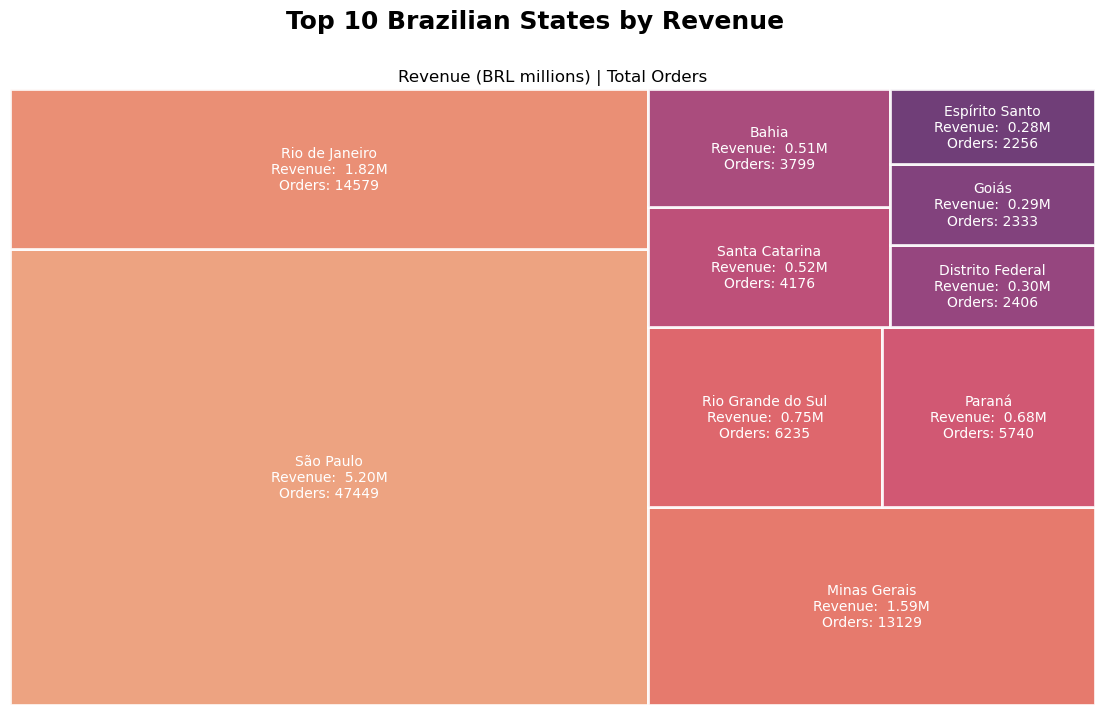

In [425]:
import squarify


revenue_per_state = connection.execute("""SELECT COUNT(orders.order_id) AS total_orders, customer_state, ROUND(SUM(order_item.price),2) AS total_revenue
                      FROM orders
                      INNER JOIN customer
                      ON orders.customer_id = customer.customer_id
                      INNER JOIN order_item
                      ON orders.order_id = order_item.order_id
                      GROUP BY customer_state
                      ORDER BY total_orderS DESC;""").df().head(10)

# dictionary containing full names of states
state_full_names = {
    "AC": "Acre",
    "AL": "Alagoas",
    "AP": "Amapá",
    "AM": "Amazonas",
    "BA": "Bahia",
    "CE": "Ceará",
    "DF": "Distrito Federal",
    "ES": "Espírito Santo",
    "GO": "Goiás",
    "MA": "Maranhão",
    "MT": "Mato Grosso",
    "MS": "Mato Grosso do Sul",
    "MG": "Minas Gerais",
    "PA": "Pará",
    "PB": "Paraíba",
    "PR": "Paraná",
    "PE": "Pernambuco",
    "PI": "Piauí",
    "RJ": "Rio de Janeiro",
    "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul",
    "RO": "Rondônia",
    "RR": "Roraima",
    "SC": "Santa Catarina",
    "SP": "São Paulo",
    "SE": "Sergipe",
    "TO": "Tocantins"
}

# adding full names to dataframe
revenue_per_state['state_full'] = revenue_per_state['customer_state'].map(state_full_names)

#building treemap labels using full names + revenue +orders

labels = [
    f"{row.state_full}\n"
    f"Revenue: {row.total_revenue/1e6: .2f}M\n"
    f"Orders: {row.total_orders}"
    for _, row in revenue_per_state.iterrows()
]

plt.figure(figsize=(14,8))
squarify.plot(
    sizes=revenue_per_state['total_revenue'],
    label= labels,
    color=sns.color_palette('flare', len(revenue_per_state)),
    alpha=0.9,
    text_kwargs = {'fontsize' : 10, 'color': 'white', 'wrap':True},
    edgecolor = 'white',
    linewidth = 2
)
#plt.title('Revenue & Orders by State')
plt.axis('off')
plt.suptitle(
    "Top 10 Brazilian States by Revenue",
    fontsize=18, fontweight='bold'
)
plt.title(
    "Revenue (BRL millions) | Total Orders",
    fontsize=12
)

plt.savefig('top10_states_by_revenue')

plt.show()

<a id='business-question-9'></a>
## Business question 9: 
Which states generate the most orders and revenue?

### Approach:
The Orders, Customers and Order Items tables were joined to calculate total orders and total revenue per customer state. Results were grouped by state and ordered by total revenue.

## Key Findings:
**SP Dominates the Platform**
São Paulo (SP) is by far the largest market on Olist, generating 47,449 orders and BRL 5,202,955.05 in total revenue. The second largest state, Rio de Janeiro (RJ), generates 14,579 orders and BRL 1,824,092.67 meaning SP produces approximately three times more orders and nearly three times more revenue than RJ.

This finding is consistent with Business Question 5, where 9 out of 10 top revenue generating sellers were also based in SP. Both customer 
demand and seller supply are heavily concentrated in Brazil's most populous and economically active state.

**Limited Reach in Smaller States**
States including Acre (AC), Amapá (AP) and Roraima (RR) each generate fewer than 100 orders, suggesting Olist has very limited presence in 
Brazil's northern and remote regions. These states likely face additional challenges around logistics and delivery infrastructure which may be deterring both sellers and customers.

**Geographic Concentration Risk**
Olist's heavy reliance on SP creates a significant business risk. Any economic downturn, regulatory change or increased competition specifically in SP could have a disproportionate impact on overall platform revenue. A more geographically diversified customer and seller base would make the business more resilient.

## Business Recommendations:
 - Olist should develop targeted marketing campaigns for underperforming states, particularly MG, RS and PR which show reasonable order volumes 
  but have room to grow.
- Logistics partnerships in northern states such as AM, AC and AP should be explored to reduce delivery barriers and make the platform more accessible to customers in remote regions.
- Seller recruitment campaigns outside SP should be prioritised to reduce geographic concentration risk and improve delivery times for 
  customers in other states.
- The strong performance of SP should be studied to understand what is driving success there whether it is population density, logistics infrastructure or marketing investment and replicate those conditions in other key states.


In [321]:
# Getting top 10 products with highest revenue 

connection.execute("""
                    SELECT 
                    eng.product_category_name_english AS product_name, SUM(order_item.price) AS total_revenue
                    FROM  order_item
                    
                    
                    
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english
                    ORDER BY total_revenue DESC
                    LIMIT 10;
                    """).df()

,product_name,total_revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


In [323]:
#1st query

connection.execute("""
                    SELECT eng.product_category_name_english AS product_name, SUM(order_item.price) AS total_revenue
                    
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english
                    ORDER BY total_revenue DESC
                    LIMIT 10;
                    """).df()

,product_name,total_revenue
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


In [324]:
# 2nd query

connection.execute("""
                   SELECT COUNT(order_item.order_id) AS total_orders, eng.product_category_name_english AS product_name,
                   ROUND(AVG(review_score),2) AS avg_review_score
                   
                   FROM order_item
                   

                   LEFT JOIN reviews
                   ON order_item.order_id = reviews.order_id

                   INNER JOIN products
                   ON order_item.product_id = products.product_id

                   LEFT JOIN product_name_english AS eng
                   ON products.product_category_name = eng.product_category_name
                   
                   WHERE review_score IS NOT NULL
                   GROUP BY eng.product_category_name_english
                  
                   ORDER BY avg_review_score DESC
                   
                   
                   """).df()

,total_orders,product_name,avg_review_score
0,14,cds_dvds_musicals,4.64
1,8,fashion_childrens_clothes,4.50
2,549,books_general_interest,4.45
3,99,costruction_tools_tools,4.44
4,31,flowers,4.42
...,...,...,...
67,131,fashion_male_clothing,3.64
68,27,home_comfort_2,3.63
69,1687,office_furniture,3.49
70,39,diapers_and_hygiene,3.26


In [325]:
# USING CTEs (Common Table Expressions):
# Instead of nesting subqueries within each other I am using CTE to define each query seperately and then combine them.

connection.execute("""WITH revenue_data AS (
                      SELECT eng.product_category_name_english AS product_name, SUM(order_item.price) AS total_revenue
                    
                    FROM order_item
                    INNER JOIN products
                    ON order_item.product_id = products.product_id
                    
                    LEFT JOIN product_name_english AS eng
                    ON products.product_category_name = eng.product_category_name
                    GROUP BY eng.product_category_name_english),
                    review_data AS (
                    SELECT COUNT(order_item.order_id) AS total_orders, eng.product_category_name_english AS product_name,
                    ROUND(AVG(review_score),2) AS avg_review_score
                   
                    FROM order_item
                   

                   LEFT JOIN reviews
                   ON order_item.order_id = reviews.order_id

                   INNER JOIN products
                   ON order_item.product_id = products.product_id

                   LEFT JOIN product_name_english AS eng
                   ON products.product_category_name = eng.product_category_name
                   
                   WHERE review_score IS NOT NULL
                   GROUP BY eng.product_category_name_english)
                   SELECT revenue_data.product_name, total_revenue, avg_review_score, total_orders
                   FROM revenue_data
                   INNER JOIN review_data
                   ON revenue_data.product_name = review_data.product_name
                   ORDER BY total_revenue DESC
                   LIMIT 10;""").df()

,product_name,total_revenue,avg_review_score,total_orders
0,health_beauty,1258681.34,4.14,9645
1,watches_gifts,1205005.68,4.02,5950
2,bed_bath_table,1036988.68,3.90,11137
3,sports_leisure,988048.97,4.11,8640
4,computers_accessories,911954.32,3.93,7849
5,furniture_decor,729762.49,3.90,8331
6,cool_stuff,635290.85,4.15,3772
7,housewares,632248.66,4.06,6943
8,auto,592720.11,4.07,4213
9,garden_tools,485256.46,4.04,4329


<a id='business-question-10'></a>
## Business Question 10: 
Based on Revenue and Reviews, Which Product Categories Should Be Prioritised in Future Marketing?

### Approach
This analysis combines total revenue, average review score and total orders per product category to identify which categories represent the strongest marketing investment opportunity. Categories were ranked by total revenue and assessed against review scores to ensure recommendations are supported by both commercial performance and customer satisfaction.

### Key Findings

**Health and Beauty**
Health and Beauty is the strongest performing category on the platform, generating BRL 1,258,681.34 in total revenue from 9,645 orders with an average review score of 4.14. High revenue, high volume and strong customer satisfaction make this the most reliable category on Olist. This finding is consistent with Business Question 1 where Health and Beauty ranked as the top revenue generating category.

**Watches and Gifts: High Value Product**
Watches and Gifts generates BRL 1,205,005.68 almost matching Health and Beauty but from only 5,950 orders. This means customers are spending significantly more per transaction in this category, confirming the high average order value identified in Business Question 8. With a review score of 4.02, customer satisfaction is strong. The relatively low order volume suggests this category has significant untapped potential, more customers buying at the same average spend would rapidly increase revenue.

**Bed Bath Table: Volume Without Efficiency**
Bed Bath Table generates BRL 1,036,988.68 but requires 11,137 orders to do so, more orders than the top two categories combined. Its review score of 3.90 is the lowest in the top 10. This suggests the category relies on volume rather than value, and the lower satisfaction score may be limiting repeat purchases.

**Cool Stuff: Highest Review Score**
Cool Stuff ranks seventh in revenue at BRL 635,290.85 but achieves the highest review score in the top 10 at 4.15 and does so from only 3,772 orders. This combination of high satisfaction and strong revenue per order suggests significant growth potential. With the rise of social media influence and trending product culture, this category is well positioned to attract a younger, digitally engaged customer base if marketed correctly.

### Business Recommendations
- **Health and Beauty** should remain the primary marketing focus as it delivers consistently across all three measures: revenue, volume and customer satisfaction.
- **Watches and Gifts** should be prioritised for seasonal campaigns, particularly around Christmas, Valentine's Day and Mother's Day when gifting demand peaks. Increasing order volume in this category while maintaining the high average transaction value would significantly boost overall revenue.
- **Cool Stuff** represents the strongest growth opportunity on the platform. Olist should invest in social media marketing campaigns targeting younger audiences to capitalise on trending product culture. Given its high review score, satisfied customers are already showing interest and trend in this category.
- **Bed Bath Table** should be reviewed for product quality and customer experience improvements before significant additional marketing spend is committed, given its below average review score relative to the top performing categories.
- Future marketing planning should combine all three metrics: revenue, order volume and review score rather than relying on revenue alone, as high revenue categories with low satisfaction scores risk long term customer retention issues.